# GOBAI-O2 v2.3 to materialized Icechunk on Source Cooperative

This notebook writes the local GOBAI-O2 v2.3 NetCDF dataset to `fish-pace/GOBAI-O2` as materialized Zarr v3 chunks in an Icechunk repository. It does **not** use VirtualiZarr or virtual references.

Before running the write, authenticate with the Source Cooperative CLI if necessary:

```bash
/home/jovyan/.cargo/bin/source-coop login --duration 1d --port 8400
```

In [1]:
%pip install -qU icechunk xarray dask netCDF4 zarr

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires cf_xarray>=0.6.0, which is not installed.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.
distributed 2025.11.0 requires dask==2025.11.0, but you have dask 2026.7.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import dask
import icechunk
import numpy as np
import xarray as xr

print(f"icechunk={icechunk.__version__}, xarray={xr.__version__}, dask={dask.__version__}")

icechunk=2.1.2, xarray=2026.7.0, dask=2026.7.1


## 1. Open and inspect the source

The dataset remains lazy. The report includes dimensions, variables, coordinates, data types, attributes, source encoding/chunking, and estimated uncompressed sizes.

In [2]:
import xarray as xr

chunks = {
    "time": 14,
    "pres": 2,
    "lat": 73,
    "lon": 120,
}

ds = xr.open_dataset(
    "~/shared-public/GOBAI-O2-v2.3.nc",
    chunks=chunks,
    engine="h5netcdf",  # netcdf4 is also reasonable
)

ds

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>

## 2. Prepare CF and discovery metadata

The source has useful variable descriptions but no global attributes. The changes below:

- retain source descriptions and provenance;
- add authoritative GOBAI-O2 citation, DOI, creators, license, and references;
- identify the coordinate axes and use CF-compatible units;
- identify oxygen, temperature, and practical salinity with valid CF standard names;
- leave uncertainty without a `standard_name`, because the CF table has no exact standard name for this product's combined oxygen uncertainty;
- link `uncer` to `oxy` as an ancillary variable.

References: [GOBAI-O2](https://www.pmel.noaa.gov/gobai/), [NCEI Accession 0259304](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:0259304), and [Sharp et al. (2023)](https://doi.org/10.5194/essd-15-4481-2023).

In [3]:
prepared = ds.copy(deep=False)
prepared.attrs.update(
    {
        "Conventions": "CF-1.12, ACDD-1.3",
        "title": "GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interior Dissolved Oxygen",
        "summary": (
            "Monthly global fields of ocean interior dissolved oxygen, total uncertainty, "
            "temperature, and salinity produced using observations and machine learning."
        ),
        "source": (
            "GOBAI-O2 v2.3; machine-learning dissolved oxygen fields with Roemmich and "
            "Gilson (2009) temperature and salinity fields"
        ),
        "history": (
            f"{datetime.now(timezone.utc).isoformat()}: converted from GOBAI-O2-v2.3.nc "
            "to materialized Zarr v3 in Icechunk using Xarray"
        ),
        "creator_name": (
            "Jonathan D. Sharp, Andrea J. Fassbender, Brendan R. Carter, "
            "Gregory C. Johnson, John P. Dunne, Cristina Schultz"
        ),
        "creator_institution": "NOAA Pacific Marine Environmental Laboratory and collaborators",
        "citation": (
            "Sharp, J. D., Fassbender, A. J., Carter, B. R., Johnson, G. C., Schultz, C., "
            "Dunne, J. P. (2022). GOBAI-O2: A Global Gridded Monthly Dataset of Ocean "
            "Interior Dissolved Oxygen Concentrations Based on Shipboard and Autonomous "
            "Observations (NCEI Accession 0259304). NOAA NCEI. "
            "https://doi.org/10.25921/z72m-yz67"
        ),
        "doi": "10.25921/z72m-yz67",
        "license": "Creative Commons Attribution 4.0 International (CC BY 4.0)",
        "references": (
            "https://www.pmel.noaa.gov/gobai/; "
            "https://doi.org/10.25921/z72m-yz67; "
            "https://doi.org/10.5194/essd-15-4481-2023"
        ),
        "product_version": "2.3",
    }
)

prepared["time"].attrs.update({"standard_name": "time", "long_name": "Time", "axis": "T"})
prepared["lat"].attrs.update(
    {"standard_name": "latitude", "long_name": "Latitude", "units": "degrees_north", "axis": "Y"}
)
prepared["lon"].attrs.update(
    {"standard_name": "longitude", "long_name": "Longitude", "units": "degrees_east", "axis": "X"}
)
prepared["pres"].attrs.update(
    {
        "standard_name": "sea_water_pressure",
        "long_name": "Sea Water Pressure",
        "units": "dbar",
        "positive": "down",
        "axis": "Z",
    }
)
prepared["oxy"].attrs.update(
    {
        "standard_name": "moles_of_oxygen_per_unit_mass_in_sea_water",
        "long_name": "Dissolved Molecular Oxygen Concentration",
        "units": "umol kg-1",
        "ancillary_variables": "uncer",
    }
)
prepared["uncer"].attrs.update(
    {"long_name": "Total Uncertainty in Dissolved Molecular Oxygen Concentration", "units": "umol kg-1"}
)
prepared["temp"].attrs.update(
    {"standard_name": "sea_water_temperature", "long_name": "Sea Water Temperature", "units": "degree_Celsius"}
)
prepared["sal"].attrs.update(
    {"standard_name": "sea_water_practical_salinity", "long_name": "Sea Water Practical Salinity", "units": "1"}
)

for name in prepared.data_vars:
    prepared[name].attrs["coordinates"] = "time pres lat lon"

prepared

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.12, ACDD-1.3
    title:                GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interio...
    summary:              Monthly global fields of ocean interior dissolved o...
    source:               GOBAI-O2 v2.3; machine-learning dissolved oxygen fi...
    history:              2026-08-06T04:24:29.460636+00:00: converted from GO...
    creator_name:         Jonathan D. Sharp, Andrea J. Fassbender, Brendan R....
    creator_institution:  NOAA Pacific Marine Environmental Laboratory and co...
    citation:             Sharp, J. D., Fassbender, A. J., Carter, B. R., Joh...
    doi:                  10.25921/z72m-yz67
    license:              Creative Commons Attribution 4.0 International (CC ...
    references:           https://www.pmel.noaa.gov/gobai/; https://doi.org/1...
    product_version:      2.3

## 3. Build chunking and encoding programmatically

Each variable receives the subset of the requested dimension chunk scheme that matches its actual dimensions. One-dimensional coordinate variables are stored as one chunk. Existing fill-value encoding is copied when the source defines it; this source does not define an explicit `_FillValue`.

In [4]:
chunk_size_by_dim = {"time": 14, "pres": 2, "lat": 73, "lon": 120}


def chunks_for(variable):
    if variable.ndim <= 1:
        return variable.shape
    return tuple(min(chunk_size_by_dim.get(dim, size), size) for dim, size in zip(variable.dims, variable.shape))


encoding = {}
for name, variable in prepared.variables.items():
    variable_encoding = {"chunks": chunks_for(variable)}
    for key in ("_FillValue", "missing_value"):
        if key in ds[name].encoding:
            variable_encoding[key] = ds[name].encoding[key]
    encoding[name] = variable_encoding

encoding["time"].update(
    {
        "units": ds["time"].encoding.get("units", "days since 1950-01-01"),
        "calendar": ds["time"].encoding.get("calendar", "proleptic_gregorian"),
        "dtype": ds["time"].encoding.get("dtype", "float32"),
    }
)

dask_chunks = {
    dim: min(size, prepared.sizes[dim])
    for dim, size in chunk_size_by_dim.items()
    if dim in prepared.dims
}
prepared = prepared.chunk(dask_chunks)

for name, variable_encoding in encoding.items():
    print(f"{name}: dimensions={prepared[name].dims}, encoding={variable_encoding}")

oxy: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
uncer: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
temp: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
sal: dimensions=('time', 'pres', 'lat', 'lon'), encoding={'chunks': (14, 2, 73, 120)}
lon: dimensions=('lon',), encoding={'chunks': (360,)}
lat: dimensions=('lat',), encoding={'chunks': (145,)}
pres: dimensions=('pres',), encoding={'chunks': (58,)}
time: dimensions=('time',), encoding={'chunks': (252,), 'units': 'days since 1950-01-01', 'calendar': 'proleptic_gregorian', 'dtype': dtype('<f4')}


## 4. Configure Source Cooperative storage

This uses the same Source Cooperative CLI credential cache, S3 endpoint, path-style addressing, and Icechunk repository create/open pattern as the existing GlobColour notebook.

In [6]:
SOURCE_COOP_CLI = Path("/home/jovyan/.cargo/bin/source-coop")
SOURCE_COOP_CREDS = Path("/home/jovyan/.cache/source-coop/credentials/_default.json")
BUCKET = "fish-pace"
PREFIX = "gobai-o2/monthly"
BRANCH = "main"


def get_source_credentials():
    subprocess.run([SOURCE_COOP_CLI, "creds"], check=True, stdout=subprocess.DEVNULL)
    with SOURCE_COOP_CREDS.open() as file:
        cached = json.load(file)

    expiration = datetime.fromisoformat(cached["expiration"])
    if expiration.tzinfo is None:
        expiration = expiration.replace(tzinfo=timezone.utc)
    if expiration <= datetime.now(timezone.utc):
        raise RuntimeError("Source Cooperative credentials have expired; log in again before writing")

    return {
        "access_key_id": cached["access_key_id"],
        "secret_access_key": cached["secret_access_key"],
        "session_token": cached["session_token"],
    }, expiration


credentials, expiration = get_source_credentials()
storage = icechunk.s3_storage(
    bucket=BUCKET,
    prefix=PREFIX,
    region="us-east-1",
    endpoint_url="https://data.source.coop",
    force_path_style=True,
    access_key_id=credentials["access_key_id"],
    secret_access_key=credentials["secret_access_key"],
    session_token=credentials["session_token"],
)

try:
    repo = icechunk.Repository.create(storage)
    print("Created new Icechunk repository")
except icechunk.IcechunkError:
    repo = icechunk.Repository.open(storage)
    print("Opened existing Icechunk repository")

print(f"Credentials expire at {expiration.isoformat()}")

Opened existing Icechunk repository
Credentials expire at 2026-08-06T14:48:10.187000+00:00


## 5. Write and commit materialized Zarr v3 data

`Dataset.to_zarr` performs a standard Xarray write into the Icechunk session store. Dask streams the requested chunks from NetCDF rather than loading the full dataset into memory. Re-running this cell replaces the root Zarr hierarchy in a new Icechunk snapshot.

In [7]:
session = repo.writable_session(BRANCH)

with dask.config.set({"array.slicing.split_large_chunks": True}):
    prepared.to_zarr(
        session.store,
        mode="w",
        encoding=encoding,
        consolidated=False,
        zarr_format=3,
    )

snapshot_id = session.commit("Publish materialized GOBAI-O2 v2.3 Zarr dataset")
print(f"Committed snapshot: {snapshot_id}")

repo.create_tag("v2.3", snapshot_id)

Committed snapshot: 8DKFSNN3G386BXJS8X6G


## 6. Reopen and validate the published repository

Validation uses anonymous HTTP access to the committed repository. It checks dimensions, variables, required metadata, dtypes, requested chunk shapes, and representative values from the source without reading either complete dataset.

In [10]:
%%time
public_url = "https://data.source.coop/fish-pace/gobai-o2/monthly"
public_storage = icechunk.http_storage(public_url)
public_repo = icechunk.Repository.open(public_storage)
public_store = public_repo.readonly_session(BRANCH).store
ds = xr.open_zarr(public_store, consolidated=False, chunks={})
ds

CPU times: user 39.6 ms, sys: 9.13 ms, total: 48.7 ms
Wall time: 775 ms


<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.12, ACDD-1.3
    title:                GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interio...
    summary:              Monthly global fields of ocean interior dissolved o...
    source:               GOBAI-O2 v2.3; machine-learning dissolved oxygen fi...
    history:              2026-08-06T04:24:29.460636+00:00: converted from GO...
    creator_name:         Jonathan D. Sharp, Andrea J. Fassbender, Brendan R....
    creator_institution:  NOAA Pacific Marine Environmental Laboratory and co...
    citation:             Sharp, J. D., Fassbender, A. J., Carter, B. R., Joh...
    doi:                  10.25921/z72m-yz67
    license:              Creative Commons Attribution 4.0 International (CC ...
    references:           https://www.pmel.noaa.gov/gobai/; https://doi.org/1...
    product_version:      2.3

CPU times: user 63.8 ms, sys: 1.83 ms, total: 65.6 ms
Wall time: 429 ms


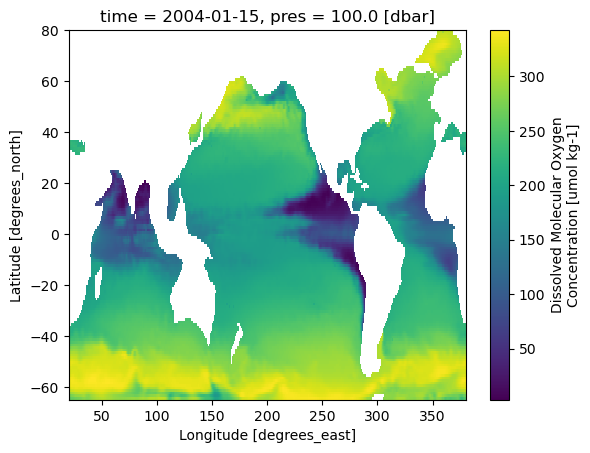

In [16]:
%%time
ds.oxy.isel(time=0, pres=10).plot()

CPU times: user 101 ms, sys: 22.4 ms, total: 124 ms
Wall time: 806 ms


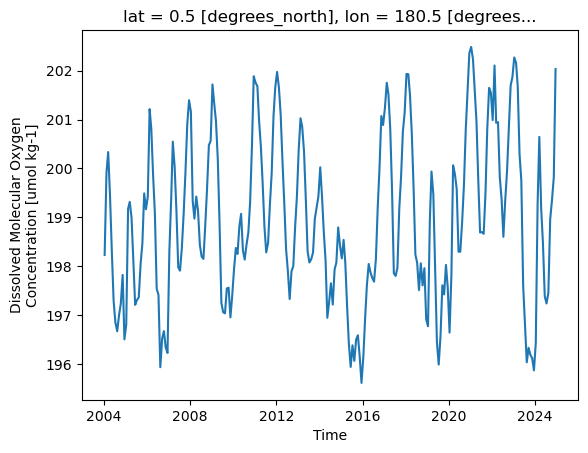

In [18]:
%%time
ds.oxy.sel(
        lat=0,
        lon=180,
        pres=ds.pres.isel(pres=0),
        method="nearest",
    ).plot()

## Validation

In [8]:
public_url = "https://data.source.coop/fish-pace/gobai-o2/monthly"
public_storage = icechunk.http_storage(public_url)
public_repo = icechunk.Repository.open(public_storage)
public_store = public_repo.readonly_session("main").store
published = xr.open_zarr(public_store, consolidated=False, chunks={})

assert dict(published.sizes) == dict(ds.sizes)
assert set(published.data_vars) == set(ds.data_vars)
assert published.attrs["product_version"] == "2.3"
assert published.attrs["doi"] == "10.25921/z72m-yz67"
assert "CF-" in published.attrs["Conventions"]

for name in ds.variables:
    assert published[name].dtype == ds[name].dtype, name
    expected_chunks = encoding[name]["chunks"]
    actual_chunks = tuple(published[name].encoding["chunks"])
    assert actual_chunks == expected_chunks, (name, actual_chunks, expected_chunks)

sample = {"time": [0, 126, 251], "pres": [0, 29, 57], "lat": [0, 72, 144], "lon": [0, 179, 359]}
source_sample = ds[list(ds.data_vars)].isel(sample).load()
published_sample = published[list(ds.data_vars)].isel(sample).load()
xr.testing.assert_allclose(published_sample, source_sample)

print("Validation passed")
print(published)

Validation passed
<xarray.Dataset> Size: 12GB
Dimensions:  (time: 252, pres: 58, lat: 145, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-15 2004-02-15 ... 2024-12-15
  * pres     (pres) float32 232B 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
  * lat      (lat) float32 580B -64.5 -63.5 -62.5 -61.5 ... 76.5 77.5 78.5 79.5
  * lon      (lon) float32 1kB 20.5 21.5 22.5 23.5 ... 376.5 377.5 378.5 379.5
Data variables:
    oxy      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    sal      (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    uncer    (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
    temp     (time, pres, lat, lon) float32 3GB dask.array<chunksize=(14, 2, 73, 120), meta=np.ndarray>
Attributes:
    Conventions:          CF-1.12, ACDD-1.3
    title:                GOBAI-O2 v2.3: Global Gridded Monthly Ocean Interio...
    s

## Troubleshooting

In [ ]:
%%script false --no-raise
# Delete everything
import json
import boto3
SOURCE_COOP_CREDS = Path("/home/jovyan/.cache/source-coop/credentials/_default.json")

with open(SOURCE_COOP_CREDS) as f:
    source_creds = json.load(f)

bucket = "fish-pace"
prefix = "gobai-o2"

s3 = boto3.client(
    "s3",
    endpoint_url=source_creds["endpoint_url"],
    region_name=source_creds["region_name"],
    aws_access_key_id=source_creds["aws_access_key_id"],
    aws_secret_access_key=source_creds["aws_secret_access_key"],
    aws_session_token=source_creds["aws_session_token"],
)

def delete_s3_prefix(bucket, prefix):
    prefix = prefix.strip("/") + "/"

    paginator = s3.get_paginator("list_objects_v2")

    # Gather keys first so changing the listing while paginating
    # does not cause objects to be skipped.
    keys = []

    for page in paginator.paginate(
        Bucket=bucket,
        Prefix=prefix,
    ):
        keys.extend(
            obj["Key"]
            for obj in page.get("Contents", [])
        )

    print(f"Found {len(keys)} objects under s3://{bucket}/{prefix}")

    for i, key in enumerate(keys, start=1):
        s3.delete_object(
            Bucket=bucket,
            Key=key,
        )

        if i % 100 == 0 or i == len(keys):
            print(f"Deleted {i} of {len(keys)} objects")

    print(f"Deleted everything under s3://{bucket}/{prefix}")


delete_s3_prefix(bucket, prefix)

In [3]:
import icechunk as ic
import xarray as xr
icechunk.__version__

'2.1.2'

In [4]:
%%time
url = "https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
storage = ic.http_storage(url)
repo = ic.Repository.open(storage)
auth = {p: ic.credentials.HttpAccess for p in repo.config.virtual_chunk_containers or []}
store = ic.Repository.open(storage, authorize_virtual_chunk_access=auth).readonly_session("main").store

ds = xr.open_zarr(store, consolidated=False, chunks=None)

CPU times: user 3.86 s, sys: 1.24 s, total: 5.1 s
Wall time: 4.59 s
